## GSEA analysis + Escape analysis for pathways 

In this notebook we use GO and KEGG terms to profile changes in pathways between the following cohorts:
- CIAO
- UKBB
- SWISS100
- New England Centenerian Study (NECS)

Approach:
0) Lists of differentially abundant proteins are already computed (cent vs control in CIAO, cent vs healthy in SWISS100, cent vs controls in NECS) + for UKBB 
1) Using GO gene set (GO_BIOLOGICAL_PROCESS = "GO_Biological_Process_2023") and KEGG database (KEGG_HUMAN = "KEGG_2021_Human") we will get pathways'-related genes. Then, for each pathway, a normalized enrichment score (NES) will be computed: separately for the UK Biobank aging direction (using Age_Beta as the ranking metric) and the centenarian direction (using Log2FC).
2) Pathways were classified as "escape" if the aging NES and centenarian NES had opposing signs. Statistical significance was assessed using permutation-based p-values with Benjamini-Hochberg correction. Pathway enrichment of differentially expressed proteins was also performed using Fisher's exact test with KEGG and Hallmark gene sets.

In [24]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy
from pathlib import Path
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = "/Users/achechenina/projects/centenerians"
PADJ_THRESH = 0.05
LOG2FC_THRESH = 0.5

### Data prep

In [18]:
# reading ciao full DE results
ciao_full = pd.read_csv(Path(PROJECT_ROOT) / "results" / "data" / "DE_basic" / "DE_basic_full.csv")
print(ciao_full.shape) 
ciao_full.head(3)

(5208, 7)


,PG.ProteinGroups,PG.Genes,PG.ProteinDescriptions,PG.ProteinNames,log2FC,pvalue,padj
0,A0A024R1R8;Q9Y2S6,TMA7B;TMA7,Translation machinery-associated protein 7B;Tr...,TMA7B_HUMAN;TMA7_HUMAN,0.170532,0.243082,0.399738
1,A0A024RBG1;Q9NZJ9,NUDT4B;NUDT4,Diphosphoinositol polyphosphate phosphohydrola...,NUD4B_HUMAN;NUDT4_HUMAN,0.044471,0.800222,0.875457
2,A0A075B6H7;A0A0C4DH55,IGKV3-7;IGKV3D-7,Probable non-functional immunoglobulin kappa v...,KV37_HUMAN;KVD07_HUMAN,1.277678,0.000190,0.003921


In [19]:
# reading ukbb betas
ukbb_full = pd.read_csv(Path(PROJECT_ROOT) / "results" / "data" / "ukbb_gene_name_preprocessed_full.csv")
print(ukbb_full.shape)
ukbb_full.head(3)

(2729, 18)


,ProteinID,Protein_name,Age_Beta,Age_SE,Age_log10p,Sex_Beta,Sex_SE,Sex_log10p,BMI_Beta,BMI_SE,BMI_log10p,Gene,Age_pvalue,Age_significant,Age_direction,gene_symbol_match,protein_id_stem,uniprot_id
0,AARSD1:Q9BTE6:OID21311:v1,Alanyl-tRNA editing protein Aarsd1,0.010334,0.000526,84.782401,0.283179,0.008432,243.876739,0.010647,0.000883,32.680552,AARSD1,1.650439e-85,True,increase,AARSD1,AARSD1,Q9BTE6
1,ABHD14B:Q96IU4:OID20921:v1,Protein ABHD14B,0.005952,0.000550,26.526876,0.115106,0.008811,38.210116,0.014309,0.000925,53.121683,ABHD14B,2.972514e-27,True,increase,ABHD14B,ABHD14B,Q96IU4
2,ABL1:P00519:OID21280:v1,Tyrosine-protein kinase ABL1,0.004479,0.000538,16.064501,0.040021,0.008619,5.463773,0.027441,0.000903,200.300619,ABL1,8.619828e-17,True,increase,ABL1,ABL1,P00519


In [20]:
# reading necs full DE results
necs_full = pd.read_csv(Path(PROJECT_ROOT) / "data/New_England_Sebastiani/cent2cont_table.csv")
print(necs_full.shape)
necs_full.head(3)

(4785, 11)


,SomaID,uniprot,geneID,FC.cont2cent,FC.off2cent,F.test,Pval.Ftest,Adj.Pvalue,Gene,log2FC.cent2cont,log2FC.cent2off
0,14042-11_3,Q8N474,SFRP1,0.299923,0.271781,115.233152,7.910000e-35,3.784940e-31,SFRP1,1.737338,1.879484
1,3045-72_2,P21246,PTN,0.424080,0.412717,112.182511,3.880000e-34,9.282900e-31,PTN,1.237592,1.276775
2,9756-6_3,Q01995,TAGLN,0.455853,0.407945,94.386544,2.740000e-30,4.370300e-27,TAGLN,1.133361,1.293553


In [21]:
# reading swiss100 full DE results
swiss100_full = pd.read_excel(
    Path(PROJECT_ROOT) / "data" / "SWISS100" / "acel70409-sup-0005-tables2.xlsx",
    sheet_name="2.a Centenarian - Healthy",
    index_col=0
)
swiss100_full['Gene'] = swiss100_full['Assay']
print(swiss100_full.shape)
swiss100_full.head(3)


(724, 12)


,Assay,OlinkID,UniProt,Panel,term,contrast,log2FoldChange,conf.low,conf.high,Adjusted_pval,Threshold,Gene
1,ACTA2,OID20079,P62736,Cardiometabolic,Group,Centenarian - Healthy,1.987067,1.635890,2.338244,1.000000e-16,Significant,ACTA2
2,ACTN4,OID20435,O43707,Inflammation,Group,Centenarian - Healthy,1.606815,1.234023,1.979607,1.000000e-16,Significant,ACTN4
3,ADA2,OID20394,Q9NZK5,Cardiometabolic,Group,Centenarian - Healthy,1.144260,0.865822,1.422697,1.000000e-16,Significant,ADA2


In [22]:
meta_dict = {'ciao': {'data': ciao_full, 'genecol': 'PG.Genes', 'log2fc_col': 'log2FC', 'padj_col': 'padj'}, # centenarian vs control
            'ukbb': {'data': ukbb_full, 'genecol': 'Gene', 'log2fc_col': 'Age_Beta', 'padj_col': 'Age_pvalue'}, # betas for age variable
            'necs': {'data': necs_full, 'genecol': 'Gene', 'log2fc_col': 'log2FC.cent2cont', 'padj_col': 'Adj.Pvalue'}, # centenarian vs control, not offspring
            'swiss100': {'data': swiss100_full, 'genecol': 'Gene', 'log2fc_col': 'log2FoldChange', 'padj_col': 'Adjusted_pval'}} # centenarian vs healthy, not geriatric

### Pathways annotation and NES calculation

General functions, setup for the following gene sets:
1. KEGG_LEGACY:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=CP:KEGG_LEGACY 
   2. Path: `/Users/achechenina/projects/centenerians/sanju_version/1_raw_data/kegg_pathways.gmt`
2. HALLMARK:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=H 
   2. Path: `/Users/achechenina/projects/centenerians/sanju_version/1_raw_data/hallmark_pathways.gmt`
3. GO Biological Processes:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=GO:BP 
   2. Path: `/Users/achechenina/projects/centenerians/data/c5.go.bp.v2026.1.Hs.symbols.gmt`
4. GO Molecular Function:
   1. Link: https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=GO:MF
   2. Path: `/Users/achechenina/projects/centenerians/data/c5.go.mf.v2026.1.Hs.symbols.gmt`

Gene sets prep:

In [ ]:
# KEGG + Hallmark gene lists from MSigDB-style GMT files (sanju raw data)
GMT_KEGG = Path(PROJECT_ROOT) / "sanju_version" / "1_raw_data" / "kegg_pathways.gmt"
GMT_HALLMARK = Path(PROJECT_ROOT) / "sanju_version" / "1_raw_data" / "hallmark_pathways.gmt"
GMT_GO_BP = Path(PROJECT_ROOT) / "data" / "c5.go.bp.v2026.1.Hs.symbols.gmt"
GMT_GO_MF = Path(PROJECT_ROOT) / "data" / "c5.go.mf.v2026.1.Hs.symbols.gmt"

def _parse_gmt(path: Path) -> dict[str, list[str]]:
    out: dict[str, list[str]] = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = [g for g in parts[2:] if g]
            out[name] = genes
    return out


KEGG_GMT = _parse_gmt(GMT_KEGG)
HALLMARK_GMT = _parse_gmt(GMT_HALLMARK)
GO_BP_GMT = _parse_gmt(GMT_GO_BP)
GO_MF_GMT = _parse_gmt(GMT_GO_MF)

# Output dirs (GSEA prerank NES tables + Fisher dotplots)
DATA_OUT = Path(PROJECT_ROOT) / "results" / "data" / "pathway_gsea_compare"
PLOT_OUT = Path(PROJECT_ROOT) / "results" / "plots" / "pathway_gsea_compare"
DATA_OUT.mkdir(parents=True, exist_ok=True)
PLOT_OUT.mkdir(parents=True, exist_ok=True)

# Combined: one pool for prerank + Fisher; BH-FDR is computed across *all* terms
COMBINED_GENE_SETS: dict[str, list[str]] = {**KEGG_GMT, **HALLMARK_GMT, **GO_BP_GMT, **GO_MF_GMT}
COMBINED_LIB = COMBINED_GENE_SETS
print(
    f"GMT gene sets: KEGG={len(KEGG_GMT)}, Hallmark={len(HALLMARK_GMT)}, GO_BP={len(GO_BP_GMT)}, GO_MF={len(GO_MF_GMT)}, combined={len(COMBINED_GENE_SETS)}"
)

GMT gene sets: KEGG=186, Hallmark=50, GO_BP=7538, GO_MF=1872, combined=9646


In [ ]:
def build_ranked_series(df, genecol, log2fc_col, padj_col):
    """
    Returns ranked gene series for GSEA (named vector)
    ranking = signed logFC weighted by significance
    """

    tmp = df[[genecol, log2fc_col, padj_col]].dropna().copy()
    # optional: filter out extreme noise
    tmp = tmp[tmp[padj_col] > 0]
    # ranking metric (recommended hybrid score)
    rank = tmp[log2fc_col] * (-np.log10(tmp[padj_col] + 1e-300))
    ranked = pd.Series(rank.values, index=tmp[genecol])
    # remove duplicates (keep max absolute signal)
    ranked = ranked.groupby(ranked.index).max()
    # sort descending (GSEA requirement)
    ranked = ranked.sort_values(ascending=False)

    return ranked


def run_gsea_prerank(ranked_series, gene_sets, out_prefix, min_size=10, max_size=500):
    """Preranked GSEA via gseapy; returns the **full** ``res2d`` table (no p/FDR filter).

    Every gene set that passes ``min_size`` / ``max_size`` overlap with the ranked
    genes is present. Non-significant pathways are included. NES is normalized to
    a permutation null, so values often sit away from 0 even for weak enrichment.
    """
    pre_res = gp.prerank(
        rnk=ranked_series,
        gene_sets=gene_sets,
        processes=4,
        permutation_num=1000,
        min_size=min_size,
        max_size=max_size,
        outdir=None,  # we save manually
        seed=42,
    )
    res = pre_res.res2d.copy()
    res = res.reset_index().rename(columns={"index": "pathway"})
    res.to_csv(f"{out_prefix}_gsea_results.csv", index=False)
    return res

Applying to all cohorts:

In [26]:
all_results = []

for cohort, cfg in meta_dict.items():

    print(f"\nRunning GSEA for {cohort}")
    df = cfg["data"]
    genecol = cfg["genecol"]
    log2fc_col = cfg["log2fc_col"]
    padj_col = cfg["padj_col"]
    # build ranking
    ranked = build_ranked_series(df, genecol, log2fc_col, padj_col)
    # run GSEA
    res = run_gsea_prerank(
        ranked_series=ranked,
        gene_sets=COMBINED_GENE_SETS,
        out_prefix=str(DATA_OUT / cohort)
    )

    res["cohort"] = cohort
    all_results.append(res)

# combine all cohorts
gsea_all = pd.concat(all_results, ignore_index=True)
gsea_all.to_csv(DATA_OUT / "ALL_COHORTS_GSEA_NES.csv", index=False)


Running GSEA for ciao


/var/folders/4c/4m_q8crs1clfghmnx8q_7b7c0000gn/T/ipykernel_2055/2643325047.py:26: DeprecationWarning: processes is deprecated; use threads
  pre_res = gp.prerank(



Running GSEA for ukbb


/var/folders/4c/4m_q8crs1clfghmnx8q_7b7c0000gn/T/ipykernel_2055/2643325047.py:26: DeprecationWarning: processes is deprecated; use threads
  pre_res = gp.prerank(



Running GSEA for necs


/var/folders/4c/4m_q8crs1clfghmnx8q_7b7c0000gn/T/ipykernel_2055/2643325047.py:26: DeprecationWarning: processes is deprecated; use threads
  pre_res = gp.prerank(



Running GSEA for swiss100


/var/folders/4c/4m_q8crs1clfghmnx8q_7b7c0000gn/T/ipykernel_2055/2643325047.py:26: DeprecationWarning: processes is deprecated; use threads
  pre_res = gp.prerank(


In [36]:
nes_table = gsea_all.pivot_table(
    index="Term",
    columns="cohort",
    values="NES",
    aggfunc="first",
)

nes_table.to_csv(DATA_OUT / "NES_MATRIX.csv")

In [41]:
gsea_all.cohort.unique()

array(['ciao', 'ukbb', 'necs', 'swiss100'], dtype=object)

In [38]:
sig = gsea_all[gsea_all["FDR q-val"] < 0.05]

sig.to_csv(DATA_OUT / "SIGNIFICANT_PATHWAYS_ALL.csv", index=False)

<Axes: xlabel='NES', ylabel='Count'>

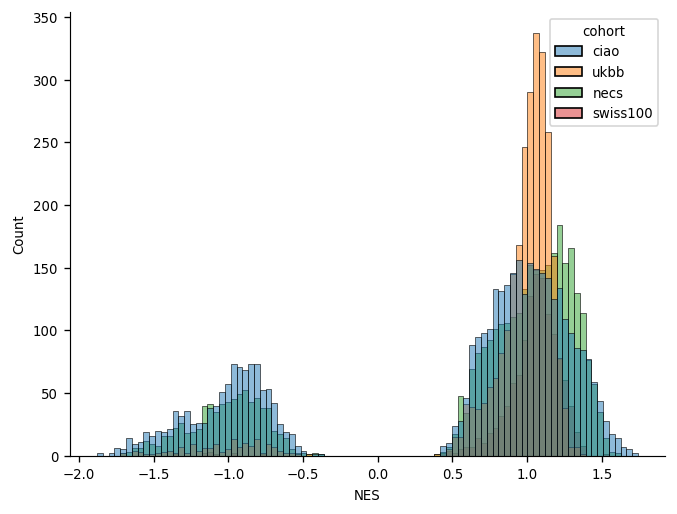

In [82]:
sns.histplot(gsea_all, x='NES', hue='cohort')

### Plotting for overlapping pathways

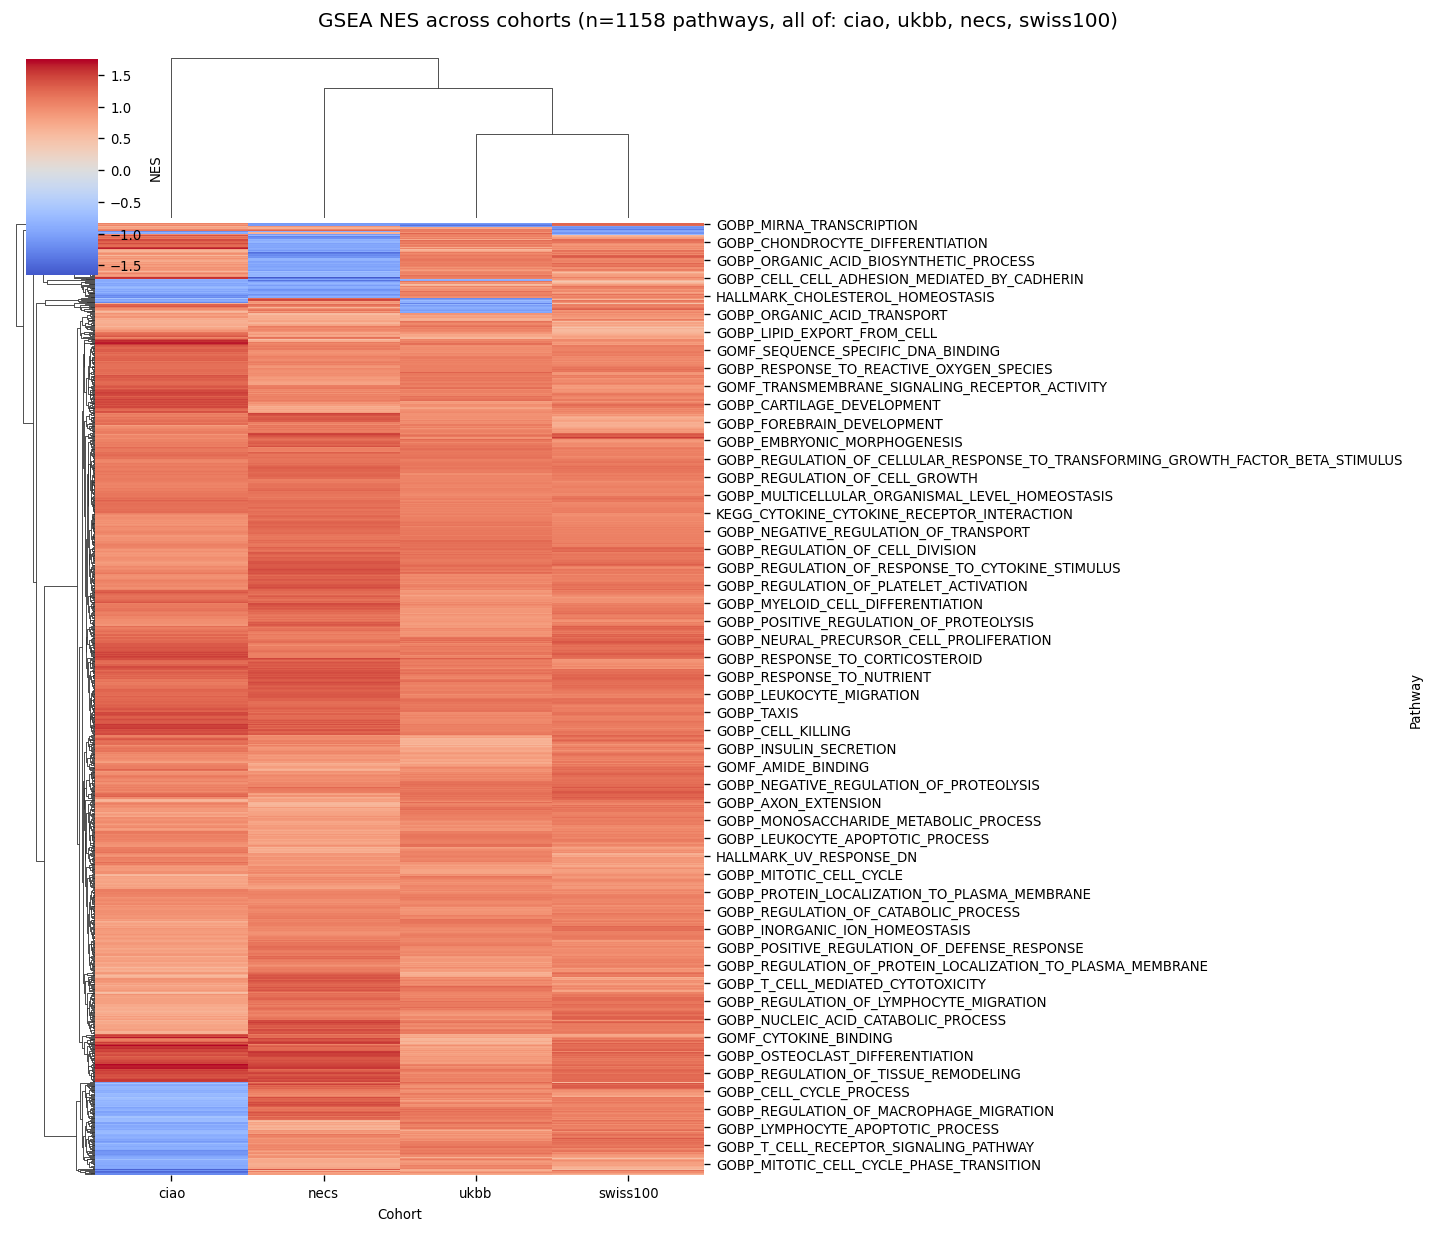

In [77]:
# Pathways with a non-null NES in every listed cohort (clustermap needs float matrix, not object)
OVERLAP_COHORTS = ["ciao", "ukbb", "necs", "swiss100"]

nt = nes_table.copy()
if isinstance(nt.columns, pd.MultiIndex):
    nt.columns = nt.columns.get_level_values(-1).astype(str)
else:
    nt.columns = nt.columns.astype(str)

cohort_cols = [c for c in OVERLAP_COHORTS if c in nt.columns]
overlap_nes = nt[cohort_cols].apply(pd.to_numeric, errors="coerce").dropna(how="any")
overlap_nes = overlap_nes.astype(np.float64)

g = sns.clustermap(
    overlap_nes,
    center=0,
    cmap="coolwarm",
    figsize=(12, 10),
    cbar_kws={"label": "NES"},
    dendrogram_ratio=(0.12, 0.15),
)
g.ax_heatmap.set_xlabel("Cohort")
g.ax_heatmap.set_ylabel("Pathway")
g.fig.suptitle(
    f"GSEA NES across cohorts (n={len(overlap_nes)} pathways, all of: {', '.join(cohort_cols)})",
    y=1.02,
    fontsize=12,
)
plt.savefig(Path(PROJECT_ROOT) / "results" / "plots" / "pathway_gsea_compare" / "overlap_nes.png")
plt.show()

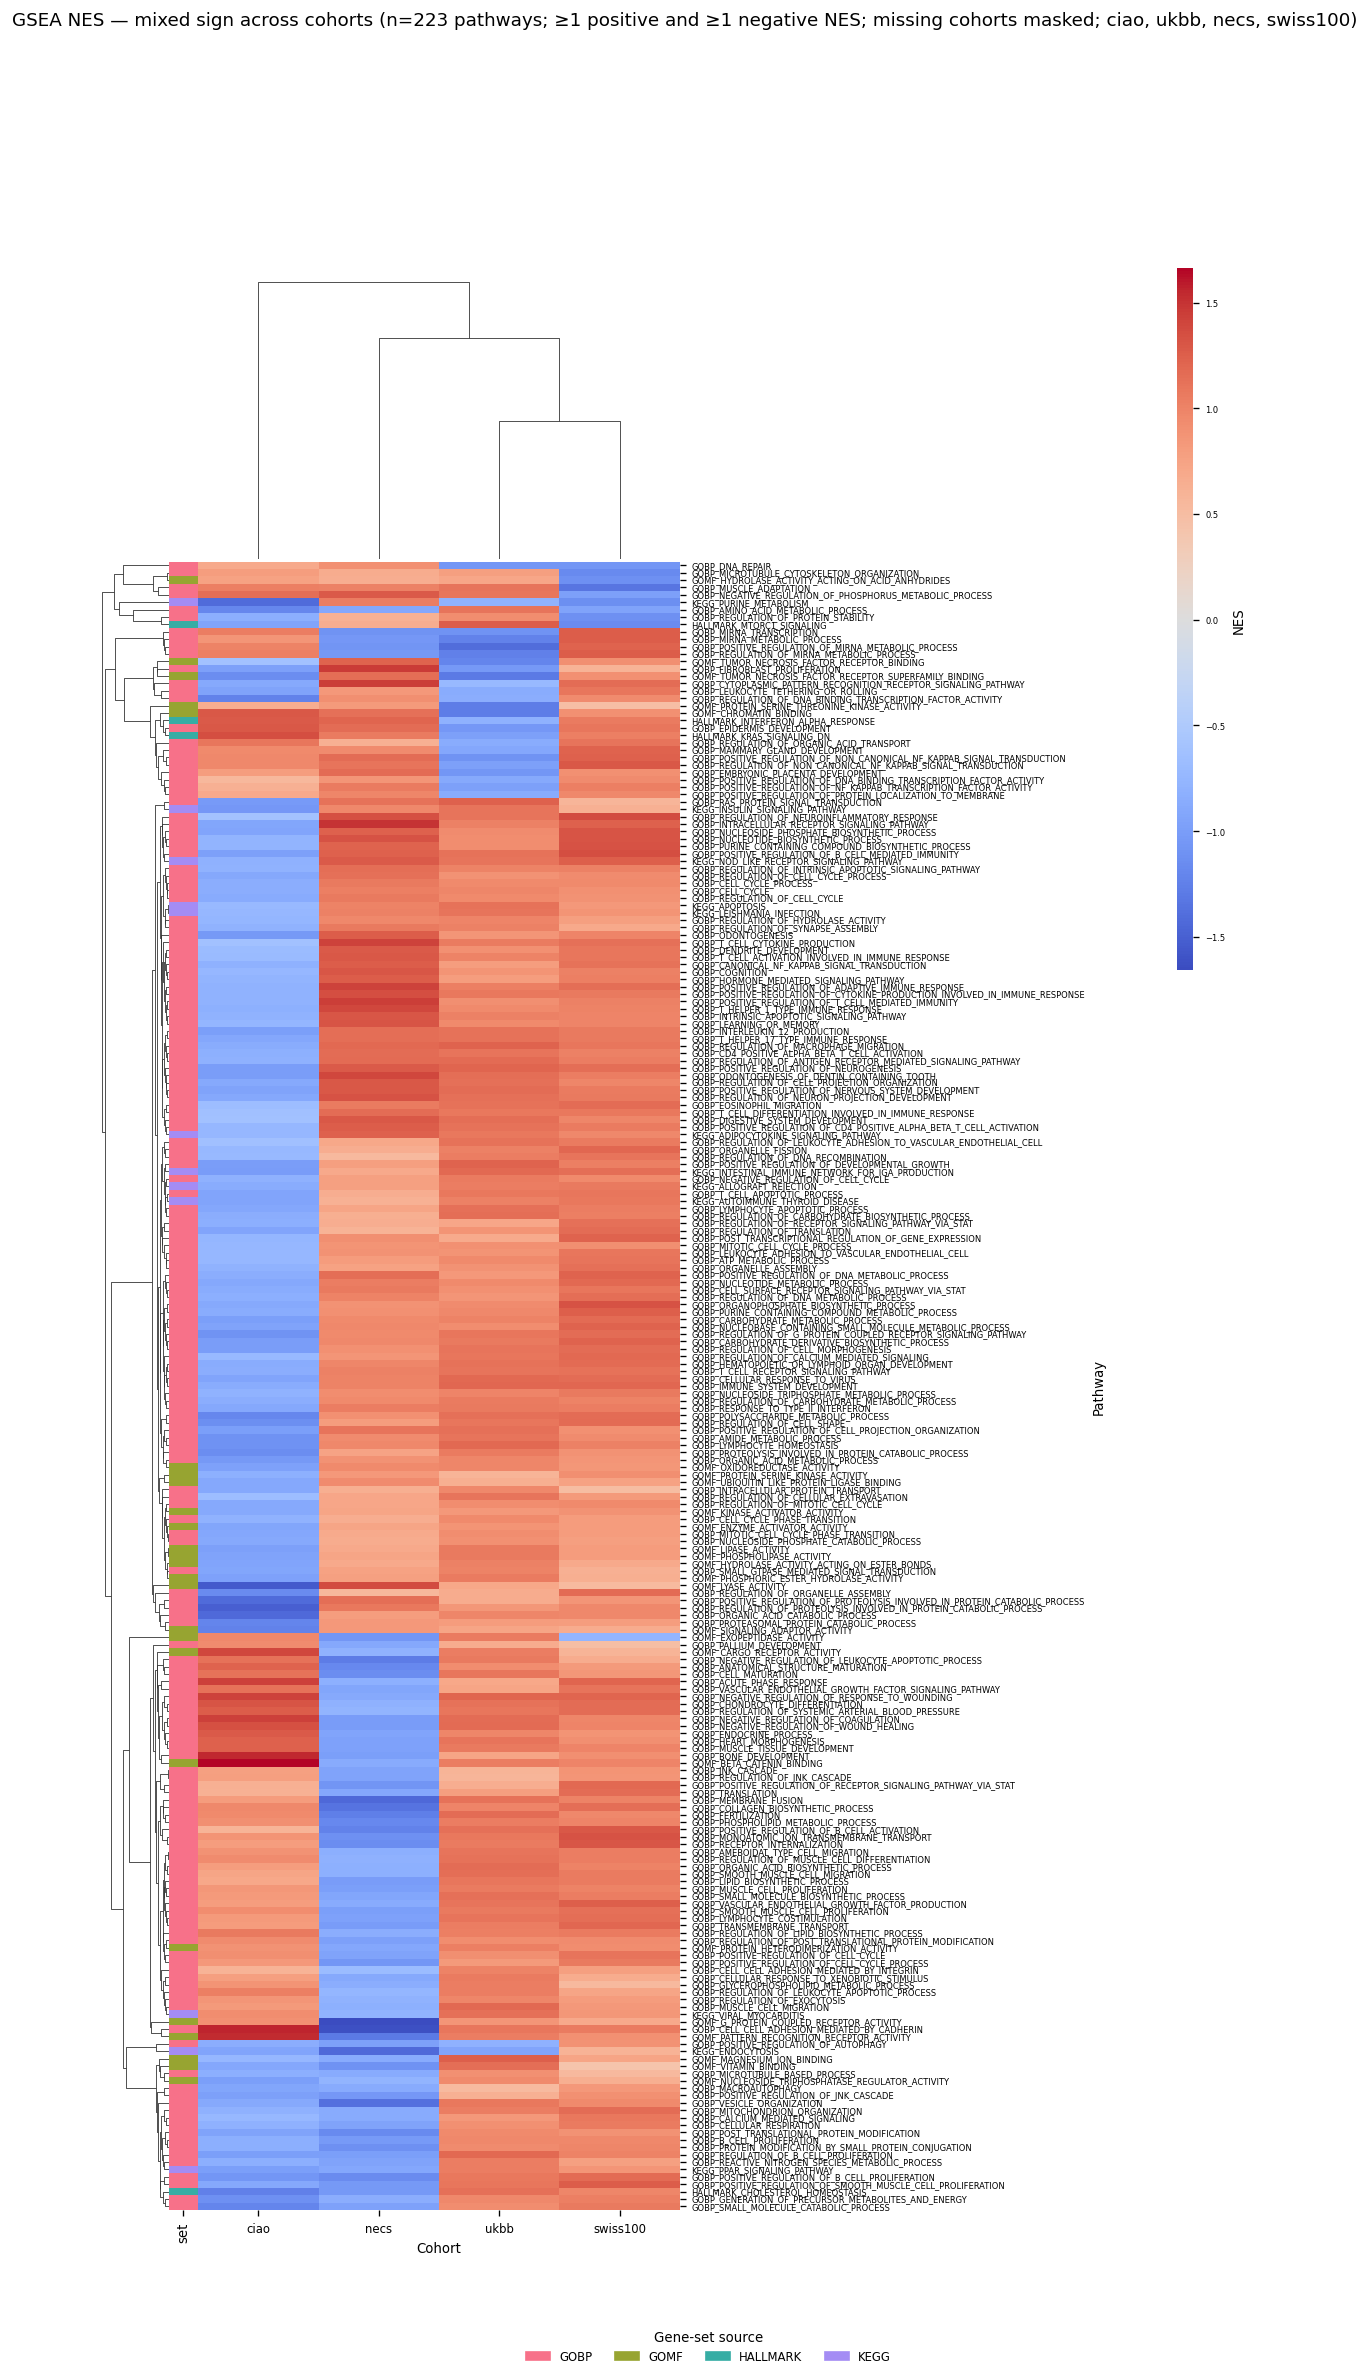

In [78]:
# Pathways with mixed NES sign across cohorts (≥1 cohort positive and ≥1 negative among finite values)
COHORTS_4 = ["ciao", "ukbb", "necs", "swiss100"]

nt = overlap_nes.copy()
if isinstance(nt.columns, pd.MultiIndex):
    nt.columns = nt.columns.get_level_values(-1).astype(str)
else:
    nt.columns = nt.columns.astype(str)

cohort_cols = [c for c in COHORTS_4 if c in nt.columns]
m = nt[cohort_cols].apply(pd.to_numeric, errors="coerce")
row_min = m.min(axis=1, skipna=True)
row_max = m.max(axis=1, skipna=True)
n_fin = m.notna().sum(axis=1)
# Both signs present among non-null NES; need at least two finite values
discord_nes = m.loc[(row_min < 0) & (row_max > 0) & (n_fin >= 2)].astype(np.float64)

if discord_nes.empty:
    print("No pathways with opposite-sign NES across these cohorts.")
else:
    from matplotlib.ticker import FixedLocator
    from matplotlib.patches import Patch

    # NaNs break scipy linkage; impute 0 for distances only, mask cells so heatmap does not show fake zeros
    _mask = discord_nes.isna()
    plot_mat = discord_nes.fillna(0.0)
    _n = len(plot_mat)
    # Tall enough for many rows; cap so the figure stays usable in the notebook
    _fig_h = max(10.0, min(95.0, 0.065 * _n + 5.0))
    _row_fs = max(1.8, min(5.0, 220.0 / max(_n ** 0.5, 1.0)))

    CBAR_RECT = [0.91, 0.60, 0.014, 0.30]

    # Gene-set source = prefix before first '_' (GOBP, KEGG, GOMF, HALLMARK, …)
    def _pathway_set(term):
        s = str(term)
        k = s.find("_")
        return s[:k] if k > 0 else "other"

    _sets = plot_mat.index.map(_pathway_set)
    _uniq = sorted(pd.Series(_sets).unique())
    _set_colors = dict(zip(_uniq, sns.color_palette("husl", n_colors=len(_uniq))))
    row_colors = pd.DataFrame({"set": pd.Series(_sets, index=plot_mat.index).map(_set_colors)})

    g = sns.clustermap(
        plot_mat,
        mask=_mask,
        center=0,
        cmap="coolwarm",
        figsize=(10.0, _fig_h),
        cbar_kws={"label": "NES"},
        dendrogram_ratio=(0.12, 0.15),
        cbar_pos=CBAR_RECT,
        row_colors=row_colors,
        colors_ratio=0.05,
    )
    hm = g.ax_heatmap
    hm.set_xlabel("Cohort")
    hm.set_ylabel("Pathway")
    # Default locator subsamples many y-ticks; force one label per (clustered) row
    _ylab = list(g.data2d.index)
    _ny = len(_ylab)
    hm.yaxis.set_major_locator(FixedLocator(np.arange(_ny) + 0.5))
    hm.set_yticklabels(_ylab, fontsize=_row_fs, va="center")
    hm.tick_params(axis="x", labelsize=max(7.0, _row_fs + 1.0))
    plt.setp(hm.get_xticklabels(), fontsize=max(7.0, _row_fs + 1.0))

    g.fig.subplots_adjust(top=0.90, bottom=0.07)
    if g.cax is not None:
        g.cax.set_position(CBAR_RECT)
        g.cax.tick_params(labelsize=max(5.0, _row_fs))
        g.cax.yaxis.set_label_position("right")
        g.cax.yaxis.tick_right()

    _leg_handles = [Patch(color=_set_colors[k], label=k) for k in _uniq]
    g.fig.legend(
        handles=_leg_handles,
        title="Gene-set source",
        ncol=min(6, len(_leg_handles)),
        loc="lower center",
        bbox_to_anchor=(0.52, 0.0),
        fontsize=7,
        title_fontsize=8,
        frameon=False,
    )

    g.fig.suptitle(
        f"GSEA NES — mixed sign across cohorts (n={len(discord_nes)} pathways; "
        f"≥1 positive and ≥1 negative NES; missing cohorts masked; {', '.join(cohort_cols)})",
        y=1.01,
        fontsize=11,
    )
    plt.savefig(Path(PROJECT_ROOT) / "results" / "plots" / "pathway_gsea_compare" / "discordant_pws_nes.png")
    plt.show()

### Plotting for individual cohorts

/var/folders/4c/4m_q8crs1clfghmnx8q_7b7c0000gn/T/ipykernel_2055/1352458544.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  _fig.tight_layout(rect=[0.0, 0.0, 0.82, 1.0])


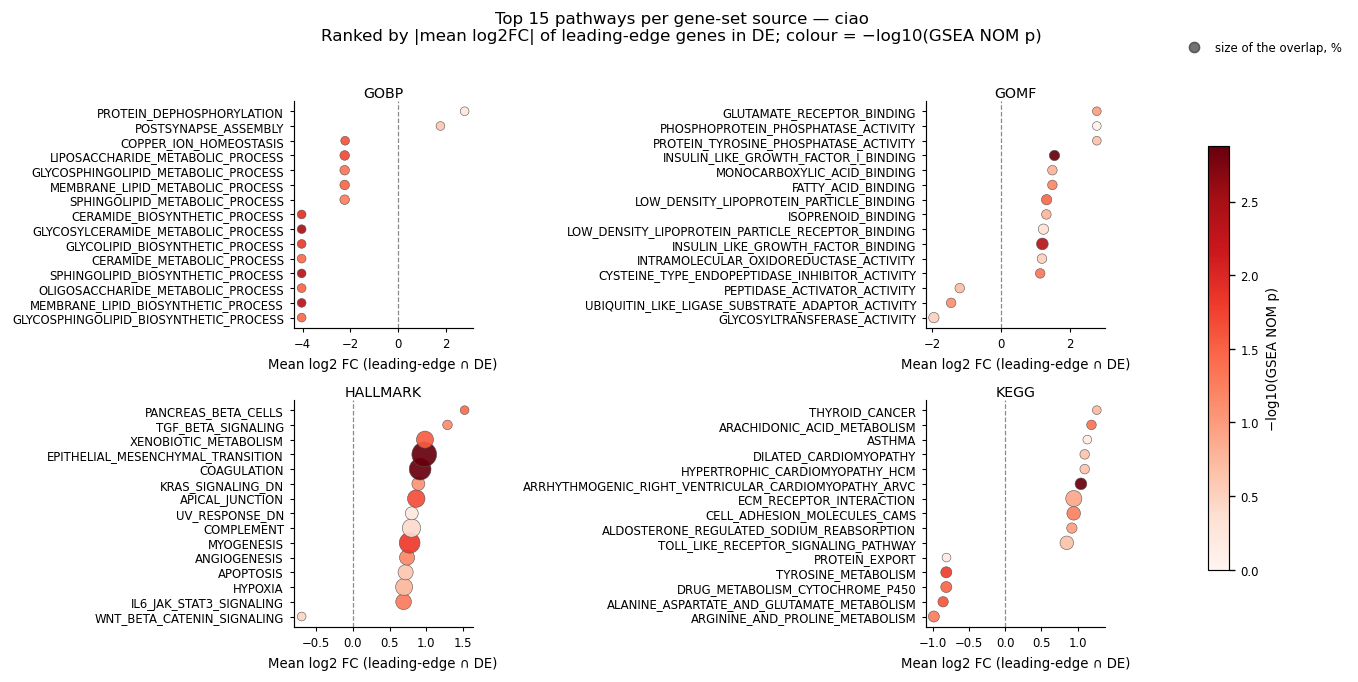

/var/folders/4c/4m_q8crs1clfghmnx8q_7b7c0000gn/T/ipykernel_2055/1352458544.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  _fig.tight_layout(rect=[0.0, 0.0, 0.82, 1.0])


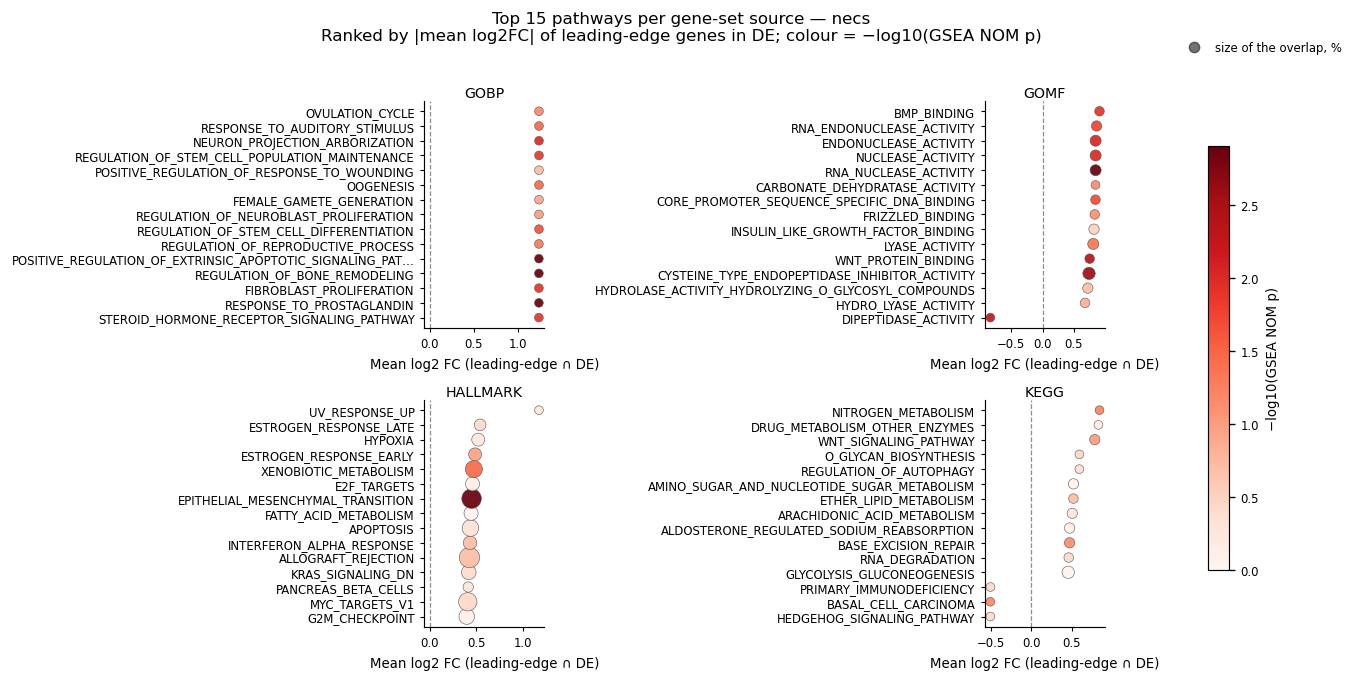

/var/folders/4c/4m_q8crs1clfghmnx8q_7b7c0000gn/T/ipykernel_2055/1352458544.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  _fig.tight_layout(rect=[0.0, 0.0, 0.82, 1.0])


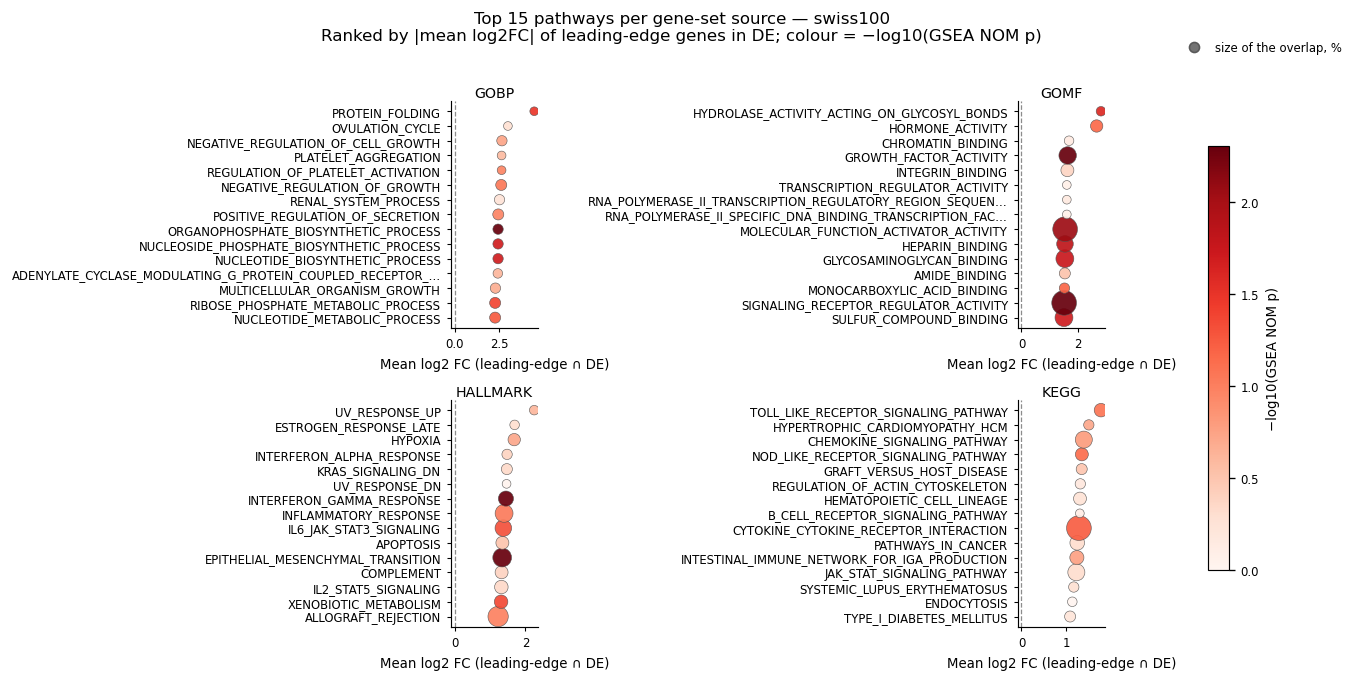

In [79]:
# Dot plots (ciao, NECS, SWISS100): top 15 pathways per gene-set source by |mean log2FC| of leading-edge genes in DE
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

PLOT_DOT = Path(PROJECT_ROOT) / "results" / "plots" / "pathway_gsea_dotplots"
PLOT_DOT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

TOP_N = 15
COHORTS_DOT = ["ciao", "necs", "swiss100"]


def _pathway_prefix(term):
    s = str(term)
    k = s.find("_")
    return s[:k] if k > 0 else "other"


def _pathway_short_label(term):
    s = str(term)
    body = s.split("_", 1)[1] if "_" in s else s
    return (body[:56] + "…") if len(body) > 56 else body


def _parse_tag_overlap(tag_pct):
    if pd.isna(tag_pct):
        return np.nan
    s = str(tag_pct).strip()
    if "/" not in s:
        return np.nan
    left = s.split("/")[0].strip()
    try:
        return float(left)
    except ValueError:
        return np.nan


def _build_gene_de_map(de_df, genecol, lfc_col, padj_col):
    rows = []
    for _, r in de_df.iterrows():
        if pd.isna(r[genecol]):
            continue
        try:
            lfc = float(r[lfc_col])
            pv = float(r[padj_col])
        except (TypeError, ValueError):
            continue
        for piece in str(r[genecol]).replace(",", ";").split(";"):
            g = piece.strip().split("|")[0].strip().upper()
            if g:
                rows.append((g, lfc, pv))
    if not rows:
        return pd.DataFrame(columns=["gene", "lfc", "padj"])
    gdf = pd.DataFrame(rows, columns=["gene", "lfc", "padj"])
    return gdf.groupby("gene", as_index=False).agg(lfc=("lfc", "mean"), padj=("padj", "min"))


def _mean_lfc_leading_edge(lead_genes, gmap):
    if pd.isna(lead_genes) or gmap.empty:
        return np.nan
    genes = [x.strip().upper() for x in str(lead_genes).split(";") if x.strip()]
    if not genes:
        return np.nan
    sub = gmap[gmap["gene"].isin(genes)]
    if sub.empty:
        return np.nan
    return float(sub["lfc"].mean())


for _coh in COHORTS_DOT:
    if _coh not in meta_dict:
        continue
    _cfg = meta_dict[_coh]
    _de = _cfg["data"]
    _gmap = _build_gene_de_map(_de, _cfg["genecol"], _cfg["log2fc_col"], _cfg["padj_col"])
    _ga = gsea_all.loc[gsea_all["cohort"] == _coh].copy()
    if _ga.empty:
        print(f"No GSEA rows for {_coh}")
        continue
    _ga["set_src"] = _ga["Term"].map(_pathway_prefix)
    _tag_col = "Tag %" if "Tag %" in _ga.columns else next((c for c in _ga.columns if "Tag" in str(c)), None)
    _ga["overlap_n"] = _ga[_tag_col].map(_parse_tag_overlap) if _tag_col is not None else np.nan
    _ga["mean_lead_lfc"] = _ga["Lead_genes"].apply(lambda s: _mean_lfc_leading_edge(s, _gmap))
    _nom = pd.to_numeric(_ga["NOM p-val"], errors="coerce").clip(lower=1e-300)
    _ga["neglog10p"] = -np.log10(_nom)

    _parts = []
    for _src, _sub in _ga.groupby("set_src"):
        _s2 = _sub.dropna(subset=["mean_lead_lfc"]).copy()
        if _s2.empty:
            continue
        _s2 = _s2.assign(_abs=np.abs(_s2["mean_lead_lfc"])).sort_values("_abs", ascending=False).head(TOP_N)
        _parts.append(_s2)
    if not _parts:
        print(f"No pathways with leading-edge mean log2FC for {_coh}")
        continue
    _plot = pd.concat(_parts, ignore_index=True)

    _sources = sorted(_plot["set_src"].unique())
    _ns = len(_sources)
    _ncol = min(5, max(2, int(np.ceil(np.sqrt(_ns)))))
    _nrow = int(np.ceil(_ns / _ncol))
    _fig, _axes = plt.subplots(_nrow, _ncol, figsize=(5 * _ncol + 1.4, 2.45 * _nrow + 0.6), squeeze=False)
    _axes = np.atleast_1d(_axes).ravel()

    _vmax = float(np.nanpercentile(_plot["neglog10p"], 95))
    _vmax = max(_vmax, 0.35)
    _norm = mcolors.Normalize(vmin=0.0, vmax=_vmax)
    _cmap = plt.cm.Reds

    for _ax, _src in zip(_axes, _sources):
        _sub = _plot.loc[_plot["set_src"] == _src].sort_values("mean_lead_lfc", ascending=True)
        if _sub.empty:
            _ax.set_visible(False)
            continue
        _y = np.arange(len(_sub))
        _ov = _sub["overlap_n"].to_numpy(dtype=float)
        _ov = np.where(np.isfinite(_ov), _ov, np.nan)
        _fallback = _sub["Lead_genes"].astype(str).str.count(";") + 1.0
        _ov = np.where(np.isfinite(_ov), _ov, _fallback.to_numpy())
        _ov = np.nan_to_num(_ov, nan=3.0)
        _pt = np.clip(22.0 + _ov * 5.5, 24.0, 220.0)
        _sc = _ax.scatter(
            _sub["mean_lead_lfc"].values,
            _y,
            s=_pt,
            c=_sub["neglog10p"].values,
            cmap=_cmap,
            norm=_norm,
            linewidths=0.35,
            edgecolors="0.32",
            alpha=0.92,
            zorder=2,
        )
        _ax.axvline(0.0, color="0.55", ls="--", lw=0.75, zorder=1)
        _ax.set_yticks(_y)
        _ax.set_yticklabels([_pathway_short_label(t) for t in _sub["Term"]], fontsize=6.2)
        _ax.set_xlabel("Mean log2 FC (leading-edge ∩ DE)")
        _ax.set_title(_src, fontsize=8.5, pad=2)
        _ax.tick_params(axis="both", labelsize=7, length=2.2, width=0.65)
        sns.despine(ax=_ax)

    for _j in range(_ns, len(_axes)):
        _axes[_j].set_visible(False)

    _sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    _sm.set_array([])
    _used = [_axes[k] for k in range(_ns)]
    # Extra pad + tighter plot rect so the colorbar sits clearly to the right of the panels
    _cbar = _fig.colorbar(
        _sm,
        ax=_used,
        fraction=0.02,
        pad=0.35,
        shrink=min(0.85, 2.6 / _nrow),
    )
    _cbar.set_label("−log10(GSEA NOM p)", fontsize=8)
    _cbar.ax.tick_params(labelsize=7)

    _handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="0.45", markeredgecolor="0.35", markersize=6, lw=0, label="size of the overlap, %"),
    ]
    _fig.legend(handles=_handles, loc="upper right", bbox_to_anchor=(0.99, 0.99), fontsize=7, frameon=False)

    _fig.suptitle(
        f"Top {TOP_N} pathways per gene-set source — {_coh}\n"
        "Ranked by |mean log2FC| of leading-edge genes in DE; colour = −log10(GSEA NOM p)",
        y=1.02,
        fontsize=10,
    )
    _fig.tight_layout(rect=[0.0, 0.0, 0.82, 1.0])
    _out = PLOT_DOT / f"dotplot_top15_by_source_{_coh}"
    #_fig.savefig(_out.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
    _fig.savefig(_out.with_suffix(".png"), bbox_inches="tight", facecolor="white")
    plt.show()

### Escape analysis on pathways 

#### CIAO - UKBB

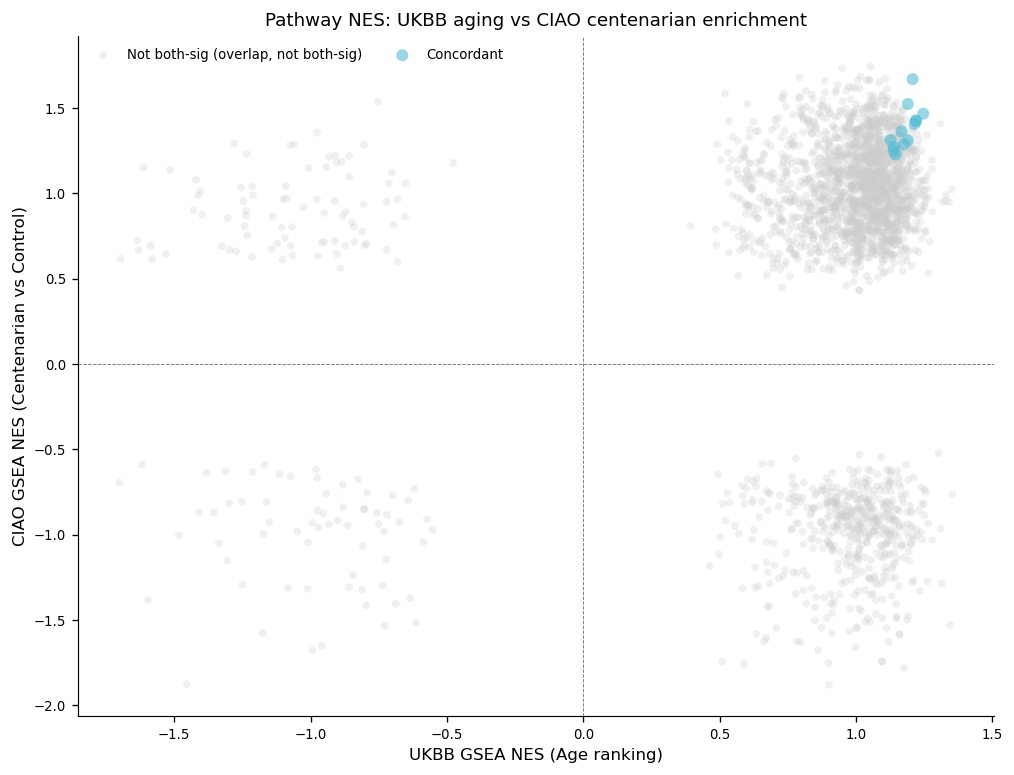

Pathway categories (NOM p < 0.05 in both cohorts → Concordant / Escape / Reversed):
Category
Not both-sig    2592
Concordant        13
Name: count, dtype: int64


In [80]:
# UKBB vs CIAO pathway NES scatter (Concordant / Escape / Reversed from NES signs only; no p-value gating)
import matplotlib.patheffects as mpe
from utils.ukbb_escape import ESCAPE_CATEGORY_COLORS

P_SCAT = Path(PROJECT_ROOT) / "results" / "plots" / "pathway_gsea_compare"
P_SCAT.mkdir(parents=True, exist_ok=True)

_nes = gsea_all.pivot_table(index="Term", columns="cohort", values="NES", aggfunc="first")
if "ciao" not in _nes.columns or "ukbb" not in _nes.columns:
    raise ValueError("gsea_all must include cohorts 'ciao' and 'ukbb'")

pw = (
    pd.DataFrame(
        {
            "NES_ciao": _nes["ciao"],
            "NES_ukbb": _nes["ukbb"],
        }
    )
    .dropna(subset=["NES_ciao", "NES_ukbb"])
    .reset_index()
)


def _pw_short_term(term):
    s = str(term)
    body = s.split("_", 1)[1] if "_" in s else s
    return (body[:46] + "…") if len(body) > 48 else body


def _pathway_category(row):
    """Classify by NES sign only (same logic as gene-level Escape/Reversed, no significance filter)."""
    nu, nc = row["NES_ukbb"], row["NES_ciao"]
    if nu * nc > 0:
        return "Concordant"
    if nu > 0 and nc < 0:
        return "Escape"
    if nu < 0 and nc > 0:
        return "Reversed"
    return "Concordant"


pw["Category"] = pw.apply(_pathway_category, axis=1)
pw["Term_lbl"] = pw["Term"].map(_pw_short_term)

C = ESCAPE_CATEGORY_COLORS
_cat_cfg = {
    "Concordant": {"color": C["Concordant"], "marker": "o", "s": 40, "alpha": 0.45, "zorder": 2, "edge": "none"},
    "Escape": {"color": C["Escape"], "marker": "s", "s": 95, "alpha": 0.88, "zorder": 5, "edge": "highlight"},
    "Reversed": {"color": C["Reversed"], "marker": "^", "s": 105, "alpha": 0.88, "zorder": 5, "edge": "highlight"},
}
_plot_order = ["Concordant", "Escape", "Reversed"]

_fig, _ax = plt.subplots(figsize=(8.5, 6.5))
for _cat in _plot_order:
    if _cat not in _cat_cfg:
        continue
    _sub = pw[pw["Category"] == _cat]
    if _sub.empty:
        continue
    _cfg = _cat_cfg[_cat]
    _edge = "white" if _cfg.get("edge") == "highlight" else "none"
    _lw = 0.35 if _edge != "none" else 0.0
    _leg = _cat
    _ax.scatter(
        _sub["NES_ukbb"],
        _sub["NES_ciao"],
        c=_cfg["color"],
        marker=_cfg["marker"],
        s=_cfg["s"],
        alpha=_cfg["alpha"],
        zorder=_cfg["zorder"],
        edgecolors=_edge,
        linewidths=_lw,
        label=_leg,
    )

_ax.axhline(0, color="#7A7876", lw=0.55, ls="--", zorder=0)
_ax.axvline(0, color="#7A7876", lw=0.55, ls="--", zorder=0)
_ax.set_xlabel("UKBB GSEA NES (Age ranking)", fontsize=10)
_ax.set_ylabel("CIAO GSEA NES (Centenarian vs Control)", fontsize=10)
_ax.set_title("Pathway NES: UKBB aging vs CIAO centenarian enrichment", fontsize=11)
_ax.legend(frameon=False, loc="best", fontsize=8, ncol=2)
sns.despine(ax=_ax)
_fig.tight_layout()

_texts = []
_halo = [mpe.withStroke(linewidth=3.0, foreground="white", capstyle="round", joinstyle="round")]
_LABEL_TOP_ESC = 8
_LABEL_TOP_REV = 8

_esc = pw[pw["Category"] == "Escape"].copy()
_rev = pw[pw["Category"] == "Reversed"].copy()
if len(_esc) and _LABEL_TOP_ESC > 0:
    _esc = _esc.assign(_m=np.abs(_esc["NES_ciao"]) + np.abs(_esc["NES_ukbb"])).sort_values("_m", ascending=False).head(_LABEL_TOP_ESC)
    for _, _r in _esc.iterrows():
        _t = _ax.annotate(
            _r["Term_lbl"],
            (_r["NES_ukbb"], _r["NES_ciao"]),
            fontsize=8,
            fontweight="bold",
            color="#2d2d2d",
            ha="center",
            va="center",
            zorder=20,
        )
        _t.set_path_effects(_halo)
        _texts.append(_t)
if len(_rev) and _LABEL_TOP_REV > 0:
    _rev = _rev.assign(_m=np.abs(_rev["NES_ciao"]) + np.abs(_rev["NES_ukbb"])).sort_values("_m", ascending=False).head(_LABEL_TOP_REV)
    for _, _r in _rev.iterrows():
        _t = _ax.annotate(
            _r["Term_lbl"],
            (_r["NES_ukbb"], _r["NES_ciao"]),
            fontsize=8,
            fontweight="bold",
            color="#1f3d36",
            ha="center",
            va="center",
            zorder=20,
        )
        _t.set_path_effects(_halo)
        _texts.append(_t)

try:
    from adjustText import adjust_text

    if _texts:
        _sx = pd.to_numeric(pw["NES_ukbb"], errors="coerce").to_numpy(dtype=float)
        _sy = pd.to_numeric(pw["NES_ciao"], errors="coerce").to_numpy(dtype=float)
        _ok = np.isfinite(_sx) & np.isfinite(_sy)
        _sx, _sy = _sx[_ok], _sy[_ok]
        _ap = dict(arrowstyle="-", color="#333333", lw=0.35, shrinkA=0, shrinkB=2)
        if len(_sx) > 0:
            adjust_text(_texts, x=_sx, y=_sy, ax=_ax, arrowprops=_ap, force_text=(1.05, 1.2), expand=(1.5, 1.6))
        else:
            adjust_text(_texts, ax=_ax, arrowprops=_ap)
except Exception:
    pass

_out = P_SCAT / "pathway_nes_ukbb_vs_ciao_escape_scatter"
_fig.savefig(_out.with_suffix(".png"), dpi=300, bbox_inches="tight", facecolor="white")
_fig.savefig(_out.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
plt.show()

print("Pathway categories (NES sign only → Concordant / Escape / Reversed):")
print(pw["Category"].value_counts())

#### NECS - UKBB

#### NECS centenarians vs offspring 

#### SWISS100 - UKBB